In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [37]:
HPV = pd.read_excel('HPV Data Capturing Tools (1).xlsx')

In [39]:
HPV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 19 columns):
 #   Column                                                              Non-Null Count  Dtype         
---  ------                                                              --------------  -----         
 0   S.No                                                                1125 non-null   int64         
 1   Date of Specimen Received by EC                                     1125 non-null   int64         
 2   Date of Specimen Received by GC                                     1125 non-null   datetime64[ns]
 3   Name of Referring Unit                                              1125 non-null   object        
 4   Name of the patient                                                 1125 non-null   object        
 5   MRN                                                                 1124 non-null   object        
 6   Barcode                                                 

In [40]:
HPV.columns

Index(['S.No', 'Date of Specimen Received by EC',
       'Date of Specimen Received by GC', 'Name of Referring Unit',
       'Name of the patient', 'MRN', 'Barcode', 'Sex', 'Age',
       'Specimen Collection Method', 'Specimen Type',
       'Reason for HPV Screening', 'HPV Result (Pos/Neg)', 'Genotype',
       'Date Tested', 'Tested by', 'Approved by', 'TAT',
       'Remark\n (Record any Remark points related to the specific patient)'],
      dtype='object')

In [41]:
HPV.shape

(1125, 19)

In [7]:
HPV.rename(columns= {"S.No": "sno",
    "Date of Specimen Received by EC": "date_received_ec",
    "Date of Specimen Received by GC": "date_received_gc",
    "Name of Referring Unit": "referring_unit",
    "Name of the patient": "patient_name",
    "MRN": "mrn",
    "Barcode": "barcode",
    "Sex": "sex",
    "Age": "age",
    "Specimen Collection Method": "collection_method",
    "Specimen Type": "specimen_type",
    "Reason for HPV Screening": "screening_reason",
    "HPV Result (Pos/Neg)": "hpv_result",
    "Genotype": "genotype",
    "Date Tested": "date_tested",
    "Tested by": "tested_by",
    "Approved by": "approved_by",
    "TAT": "tat",
    "Remark  (Record any Remark points related to the specific patient)": "remark",})

,sno,date_received_ec,date_received_gc,referring_unit,patient_name,mrn,barcode,sex,age,collection_method,specimen_type,screening_reason,hpv_result,genotype,date_tested,tested_by,approved_by,tat,Remark\n (Record any Remark points related to the specific patient)
0,1,42522,2024-02-09,Kality HC,Tirhase Hagos,174178,3001600001,Female,47,Provider,Vaginal Swab,Two-year follow-up,Negative,NaN,2024-03-27 00:00:00,Mekonen Beshada,Kebede G/tsadik,47.0,NaN
1,2,42522,2024-02-09,Kality HC,Shema Taye,073301,3001600002,Female,48,Provider,Vaginal Swab,Two-year follow-up,Rejected,NaN,45430,Abebe Worku,Sisay Tulu,99.0,missing request
2,3,42522,2024-02-09,Kality HC,Weynishet Gezu,276329,3001600003,Female,27,Provider,Vaginal Swab,New,Negative,NaN,2024-03-27 00:00:00,Mekonen Beshada,Kebede G/tsadik,47.0,NaN
3,4,42522,2024-02-09,Saris HC,Firehiwot Alemu,109763,3001600004,Female,NIF,Provider,Cervical Swab,Two-year follow-up,Negative,NaN,2024-03-27 00:00:00,Mekonen Beshada,Kebede G/tsadik,47.0,NaN
4,5,42522,2024-02-09,Saris HC,Amarech Tsegaw,85863,3001600005,Female,27,Provider,Cervical Swab,Two-year follow-up,Positive,HPV-16,2024-03-27 00:00:00,Mekonen Beshada,Kebede G/tsadik,47.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,1121,42574,2024-04-01,Bole W17 HC,kelemua haile,109056,3001601120,Female,54,NIF,Vaginal Swab,Two-year follow-up,Rejected,NaN,45429,Abebe Worku,Sisay Tulu,46.0,insufficient sample
1121,1122,42574,2024-04-01,Akaki HC,ayelu kebede,143278,3001601121,Female,53,Self,Vaginal Swab,New,Rejected,NaN,45429,Abebe Worku,Sisay Tulu,46.0,insufficient sample
1122,1123,42574,2024-04-01,Dagmawi Menilik General Hospital,aberash gelecha,NaN,3001601122,Female,42,Self,Vaginal Swab,New,Rejected,NaN,45429,Abebe Worku,Sisay Tulu,46.0,insufficient sample
1123,1124,42574,2024-04-01,Kolfe HC,ejige meshesha,170880,3001601123,Female,38,Self,NIF,New,Rejected,NaN,45429,Abebe Worku,Sisay Tulu,46.0,insufficient sample


In [43]:
HPV["Age"]= pd.to_numeric(HPV["Age"], errors= "coerce")

In [44]:
HPV["TAT"]= pd.to_numeric(HPV["TAT"], errors="coerce")

Calculate the number and percentage of missing values in each column
to assess data quality and identify fields requiring cleaning.

In [45]:
missing = HPV.isnull().sum()
missing_pct = (missing/len(HPV)*100).round(1)
print(missing_pct)

S.No                                                                    0.0
Date of Specimen Received by EC                                         0.0
Date of Specimen Received by GC                                         0.0
Name of Referring Unit                                                  0.0
Name of the patient                                                     0.0
MRN                                                                     0.1
Barcode                                                                 0.0
Sex                                                                     0.0
Age                                                                     3.0
Specimen Collection Method                                              0.0
Specimen Type                                                           0.5
Reason for HPV Screening                                                0.0
HPV Result (Pos/Neg)                                                    2.1
Genotype    

In [46]:
HPV["Genotype"]= HPV["Genotype"].fillna("none detected")

In [47]:
df = HPV.dropna(subset=["HPV Result (Pos/Neg)"])

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1101 entries, 0 to 1124
Data columns (total 19 columns):
 #   Column                                                              Non-Null Count  Dtype         
---  ------                                                              --------------  -----         
 0   S.No                                                                1101 non-null   int64         
 1   Date of Specimen Received by EC                                     1101 non-null   int64         
 2   Date of Specimen Received by GC                                     1101 non-null   datetime64[ns]
 3   Name of Referring Unit                                              1101 non-null   object        
 4   Name of the patient                                                 1101 non-null   object        
 5   MRN                                                                 1100 non-null   object        
 6   Barcode                                                      

In [49]:
df.isnull().sum()

S.No                                                                      0
Date of Specimen Received by EC                                           0
Date of Specimen Received by GC                                           0
Name of Referring Unit                                                    0
Name of the patient                                                       0
MRN                                                                       1
Barcode                                                                   0
Sex                                                                       0
Age                                                                      34
Specimen Collection Method                                                0
Specimen Type                                                             6
Reason for HPV Screening                                                  0
HPV Result (Pos/Neg)                                                      0
Genotype    

EDA 
result count

In [50]:
tested = df[df["HPV Result (Pos/Neg)"] != "Rejected"]
pos_rate = (tested["HPV Result (Pos/Neg)"] == "Positive").mean() * 100
print(f"Positivity rate: {pos_rate:.1f}%")



Positivity rate: 33.5%


Age statistics

In [51]:
df["Age"].describe().round (1)

count    1067.0
mean       43.3
std        15.7
min        14.0
25%        36.0
50%        42.0
75%        50.0
max       453.0
Name: Age, dtype: float64

In [52]:
df['TAT'].describe().round(1)

count     1100.0
mean        22.6
std       1371.0
min     -45366.0
25%         39.0
50%         48.0
75%         56.0
max        269.0
Name: TAT, dtype: float64

result by referring unit

In [53]:
print(pd.crosstab(df["Name of Referring Unit"],df["HPV Result (Pos/Neg)"]))

HPV Result (Pos/Neg)              Negative  Negatve  Positive  Rejected
Name of Referring Unit                                                 
AHF Addis                               91        0        33         0
Addis Ketema HC                         31        0        15         0
Akaki HC                                56        0        23         4
Bole W17 HC                             52        1        30         2
Dagmawi Menilik General Hospital        37        1        25         1
General Jagema Kello                     3        0         0         0
Jagama Kelo HC                          20        0         8         0
Kality HC                               35        0        18         1
Kazanchis HC                            53        1        26         2
Kirkos HC                               11        0         5         2
Kolfe HC                                 0        0         0         2
Kotebe HC                               46        0        25   

In [54]:
df.columns

Index(['S.No', 'Date of Specimen Received by EC',
       'Date of Specimen Received by GC', 'Name of Referring Unit',
       'Name of the patient', 'MRN', 'Barcode', 'Sex', 'Age',
       'Specimen Collection Method', 'Specimen Type',
       'Reason for HPV Screening', 'HPV Result (Pos/Neg)', 'Genotype',
       'Date Tested', 'Tested by', 'Approved by', 'TAT',
       'Remark\n (Record any Remark points related to the specific patient)'],
      dtype='object')

result by screening reason

In [55]:
print(pd.crosstab(df["Reason for HPV Screening"],df["HPV Result (Pos/Neg)"]))

HPV Result (Pos/Neg)      Negative  Negatve  Positive  Rejected
Reason for HPV Screening                                       
FIve-year follow-up              4        0         5         0
NIF                             15        0         3         2
New                            304        2       173        17
One-year follow-up              34        0        24         0
Two-year follow-up             348        5       154        11


detected genotypes

In [56]:
geno = df[df["HPV Result (Pos/Neg)"]== "Positive"]["Genotype"].value_counts()


In [57]:
print(geno)

Genotype
Other HR-HPV           249
HPV-16                  44
HPV-16 & others HR      40
HPV-18                  12
HPV-18 & others HR      11
none detected            2
Mixed                    1
Name: count, dtype: int64


VISUALIZATION
HPV Result Distribution

In [58]:
fig, axes = plt.subplots(2,3, figsize=(15, 9))
fig.suptitle("HPV Screening Analysis", fontsize=15, fontweight="bold")
axes = axes.flatten()

df["HPV Result (Pos/Neg)"].value_counts().plot(
    kind="bar", ax=axes[0],
    color=["#c0392b", "#2980b9", "#e67e22"], edgecolor="white")
axes[0].set_title("HPV Result Counts")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

SCREENING REASON

In [59]:
print(df['Reason for HPV Screening'].isna().sum())

0


In [60]:
df['Reason for HPV Screening'].value_counts().plot(
    kind="bar", ax=axes[1], color="#3498db", edgecolor="white"
)
axes[1].set_title("Screening Reason")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)


In [61]:
df["Name of Referring Unit"].value_counts().plot(
    kind="barh", ax=axes[2], color="#8e44ad", edgecolor="white"
)
axes[2].set_title("Samples by Referring Unit")
axes[2].set_xlabel("Count")

# --- 4. Age Distribution

Text(0.5, 447.72222222222223, 'Count')

In [28]:
# --- 4. Age Distribution ---
df['Age'].dropna().plot(
    kind="hist", ax=axes[3], bins=10,
    color="#27ae60", edgecolor="white"
)
axes[3].set_title("Age Distribution")
axes[3].set_xlabel("Age (years)")


Text(0.5, 4.444444444444452, 'Age (years)')

In [62]:
# --- 5. TAT Distribution ---
df['TAT'].dropna().plot(
    kind="hist", ax=axes[4], bins=10,
    color="#e67e22", edgecolor="white"
)
axes[4].set_title("Turnaround Time (TAT) Distribution")
axes[4].set_xlabel("Days")


Text(0.5, 69.7222222222222, 'Days')

--Genotype Frequency (positive cases only) ---


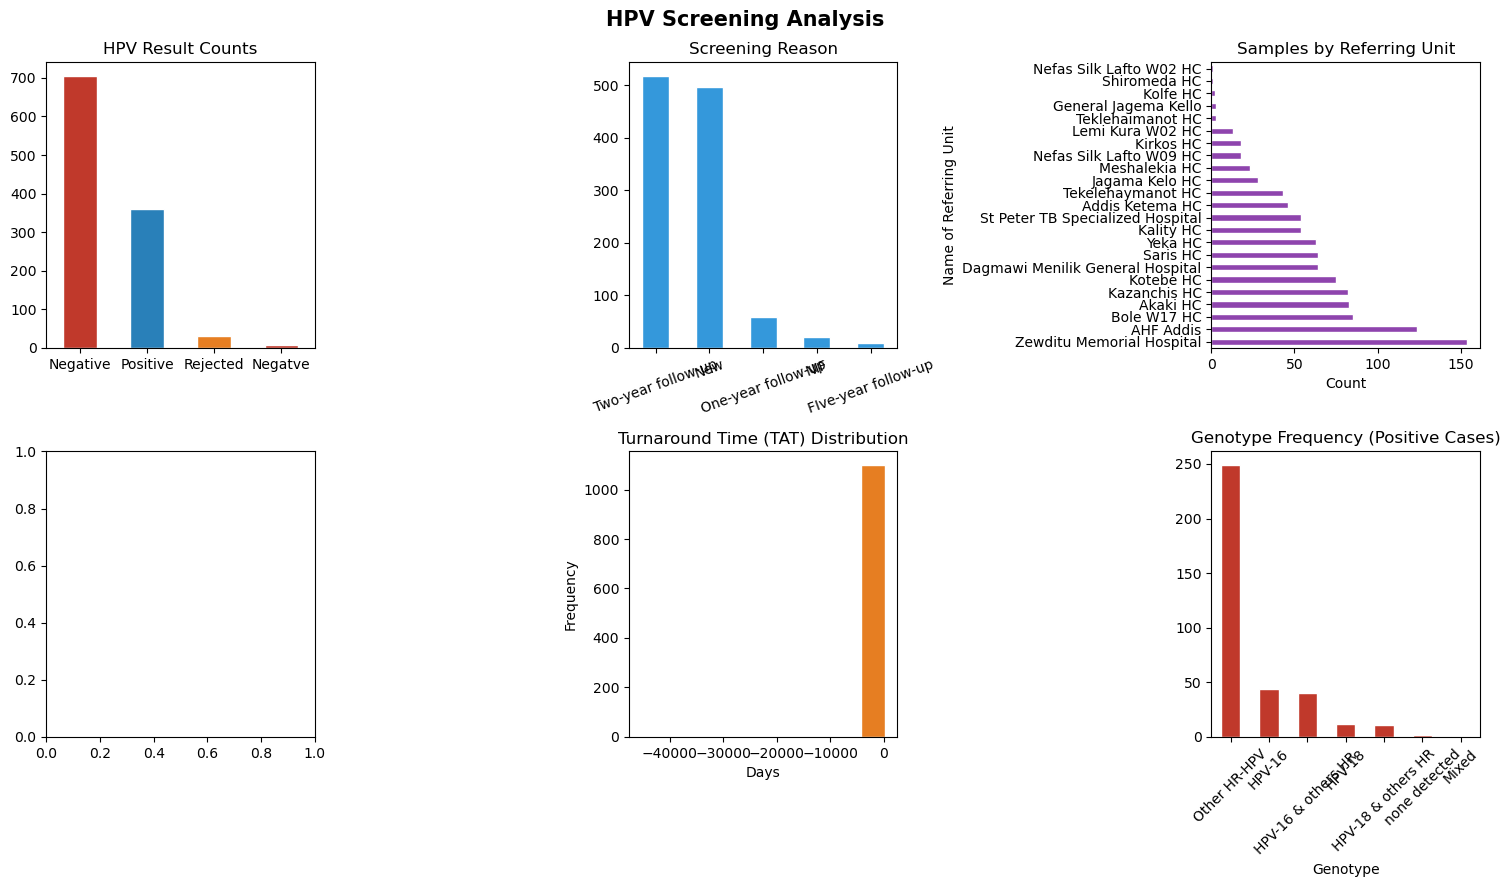

Charts saved to hpv_charts.png


In [63]:
pos = df[df['HPV Result (Pos/Neg)'].str.lower() == "positive"]
geno = pos['Genotype'].dropna()
geno = geno[geno.str.strip() != ""]
if not geno.empty:
    geno.value_counts().plot(
        kind="bar", ax=axes[5], color="#c0392b", edgecolor="white"
    )
    axes[5].set_title("Genotype Frequency (Positive Cases)")
    axes[5].tick_params(axis="x", rotation=45)
else:
    axes[5].text(0.5, 0.5, "No genotype data", ha="center", va="center",
                 transform=axes[5].transAxes, color="gray")
    axes[5].set_title("Genotype Frequency")
    axes[5].axis("off")

plt.tight_layout()
plt.savefig("hpv_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved to hpv_charts.png")
